# 04 — YOLOv11 Training

Trains a YOLOv11 variant on the unified dataset (notebook 02, health-checked in 03). Default is `yolo11s` — a good balance for an 800-image dataset.

| Variant   | Params | Speed   | When to pick |
|-----------|-------:|---------|--------------|
| `yolo11n` | ~2.6 M | fastest | edge / demo |
| `yolo11s` | ~9.4 M | fast    | **default** |
| `yolo11m` | ~20 M  | moderate| if accuracy plateaus |

In [1]:
# Install dependencies — training framework + plotting
%pip install -q "ultralytics==8.3.*" pandas matplotlib
print("nb04 base dependencies ready")

Note: you may need to restart the kernel to use updated packages.
nb04 base dependencies ready


In [2]:
# Reinstall PyTorch with the right GPU build for this machine:
#   • NVIDIA GPU (Linux/Windows, RTX/GTX) → CUDA cu126 wheel
#       (force-reinstall ensures the CUDA build wins over the +cpu wheel
#        ultralytics may have pulled in above)
#   • Apple Silicon (M1/M2/M3/M4 Mac)     → default PyPI wheel
#       (already ships with MPS / Metal GPU support — no custom index needed)
#   • Anything else                       → default wheel (CPU only)
import platform, subprocess, sys

base = [sys.executable, '-m', 'pip', 'install', '-q', '--force-reinstall',
        'torch', 'torchvision', 'torchaudio']

if sys.platform == 'darwin' and platform.machine() == 'arm64':
    print('Installing PyTorch for Apple Silicon (MPS backend)...')
    cmd = base
elif sys.platform in ('linux', 'win32'):
    print('Installing PyTorch with CUDA (cu126) — compatible with CUDA driver 12.x/13.x...')
    cmd = base + ['--index-url', 'https://download.pytorch.org/whl/cu126']
else:
    print(f'Installing PyTorch (CPU-only fallback for {sys.platform})...')
    cmd = base

subprocess.run(cmd, check=True)
print("nb04 PyTorch ready — restart kernel before running further cells")

Installing PyTorch for Apple Silicon (MPS backend)...
nb04 PyTorch ready — restart kernel before running further cells


## Imports

In [3]:
%matplotlib inline

import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/Users/th/Library/Application Support/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
# Config — paths, training hyperparameters
DATA_YAML   = Path('../data/dataset/data.yaml').resolve()  # built by notebook 02
RUNS_DIR    = Path('../runs/detect')                       # ultralytics writes here
WEIGHTS_DIR = Path('../weights')                           # promoted best.pt lands here

# Pick the best available accelerator: CUDA (NVIDIA) > MPS (Apple Silicon) > CPU
# ultralytics silently falls back to CPU if `device` isn't set, so we set it explicitly.
if torch.cuda.is_available():
    DEVICE = 0
    DEVICE_NAME = torch.cuda.get_device_name(0)
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
    DEVICE_NAME = 'Apple Silicon GPU (MPS)'
else:
    DEVICE = 'cpu'
    DEVICE_NAME = 'CPU (no GPU detected — training will be very slow)'

# Training config — change `model` to compare yolo11n / yolo11s / yolo11m
CFG = dict(
    model='yolo11n.pt',
    data=str(DATA_YAML),
    epochs=100,
    imgsz=640,
    batch=16,
    optimizer='SGD',
    lr0=0.01,
    patience=15,            # early stopping
    device=DEVICE,          # CUDA index (int), 'mps' (Apple Silicon), or 'cpu'
    project=str(RUNS_DIR),
    name='campus_yolo11s',
    seed=42,
)

assert DATA_YAML.exists(), f'missing {DATA_YAML} — run notebook 02 first'
WEIGHTS_DIR.mkdir(exist_ok=True)
print('Device :', DEVICE, f'({DEVICE_NAME})')
CFG

Device : mps (Apple Silicon GPU (MPS))


{'model': 'yolo11n.pt',
 'data': '/Users/th/github/ai_cv_project/data/dataset/data.yaml',
 'epochs': 100,
 'imgsz': 640,
 'batch': 16,
 'optimizer': 'SGD',
 'lr0': 0.01,
 'patience': 15,
 'device': 'mps',
 'project': '../runs/detect',
 'name': 'campus_yolo11s',
 'seed': 42}

# Train YOLOv11 with the configured hyperparameters
import time

model = YOLO(str(CFG['model']))

_t0 = time.time()
results = model.train(**{k: v for k, v in CFG.items() if k != 'model'})
_elapsed = time.time() - _t0

assert results is not None
run_dir = Path(results.save_dir)
print(f'run dir: {run_dir}')
print(f'Total training time: {int(_elapsed // 3600)}h {int(_elapsed % 3600 // 60)}m {int(_elapsed % 60)}s')

In [6]:
# Train YOLOv11 with the configured hyperparameters
model = YOLO(str(CFG['model']))
results = model.train(**{k: v for k, v in CFG.items() if k != 'model'})
assert results is not None
run_dir = Path(results.save_dir)
print('run dir:', run_dir)

WARNING ⚠️ Download failure, retrying 1/3 https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo11n.pt... <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1077)>


######################################################################## 100.0%


New https://pypi.org/project/ultralytics/8.4.41 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.253 🚀 Python-3.14.0 torch-2.11.0 MPS (Apple M1 Pro)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/th/github/ai_cv_project/data/dataset/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=campus_yolo11s, nbs=64, nms

## 2. Training curves
Loss + validation mAP per epoch from `results.csv`.

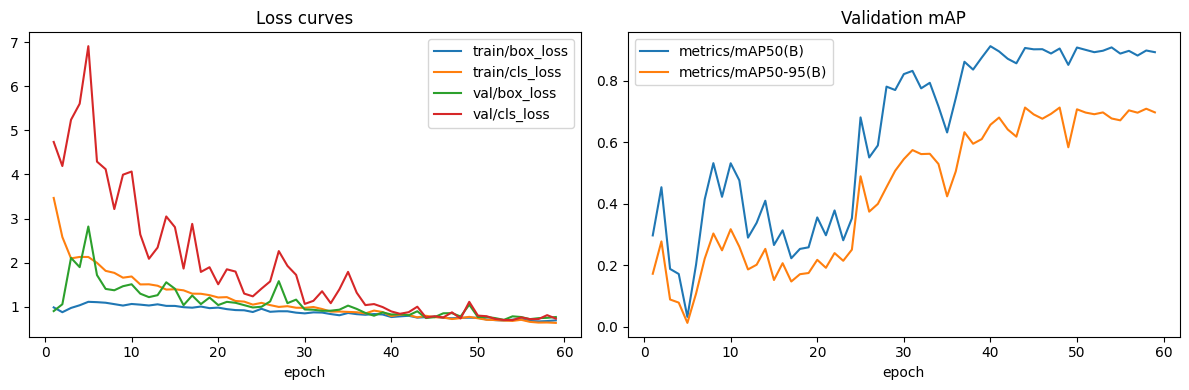

In [7]:
# Plot loss + mAP curves from results.csv
df = pd.read_csv(run_dir / 'results.csv')
df.columns = [c.strip() for c in df.columns]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df.plot(x='epoch', y=['train/box_loss', 'train/cls_loss', 'val/box_loss', 'val/cls_loss'], ax=ax[0])
ax[0].set_title('Loss curves')
df.plot(x='epoch', y=['metrics/mAP50(B)', 'metrics/mAP50-95(B)'], ax=ax[1])
ax[1].set_title('Validation mAP')
plt.tight_layout(); plt.show()

## 3. Promote best checkpoint
Copy `best.pt` from the run directory to `weights/best.pt` for downstream notebooks.

In [8]:
# Copy best.pt → weights/best.pt
best = run_dir / 'weights' / 'best.pt'
dst = WEIGHTS_DIR / 'best.pt'
shutil.copy2(best, dst)
print('saved', dst)

saved ../weights/best.pt


## 4. Quick sanity inference

In [9]:
# Predict on a few test images, save annotated outputs under <run_dir>/sanity/
test_imgs = list((Path('../data/dataset/images/test')).glob('*.jpg'))[:4]
m = YOLO(dst)
res = m.predict(source=[str(p) for p in test_imgs], imgsz=CFG['imgsz'], conf=0.25,
                save=True, project=str(run_dir), name='sanity')
print('predictions saved under', run_dir / 'sanity')


0: 640x640 1 whiteboard, 63.1ms
1: 640x640 (no detections), 63.1ms
2: 640x640 1 fire_extinguisher, 63.1ms
3: 640x640 2 projectors, 63.1ms
Speed: 4.1ms preprocess, 63.1ms inference, 3.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /Users/th/github/ai_cv_project/runs/runs/detect/campus_yolo11s/sanity
predictions saved under /Users/th/github/ai_cv_project/runs/runs/detect/campus_yolo11s/sanity


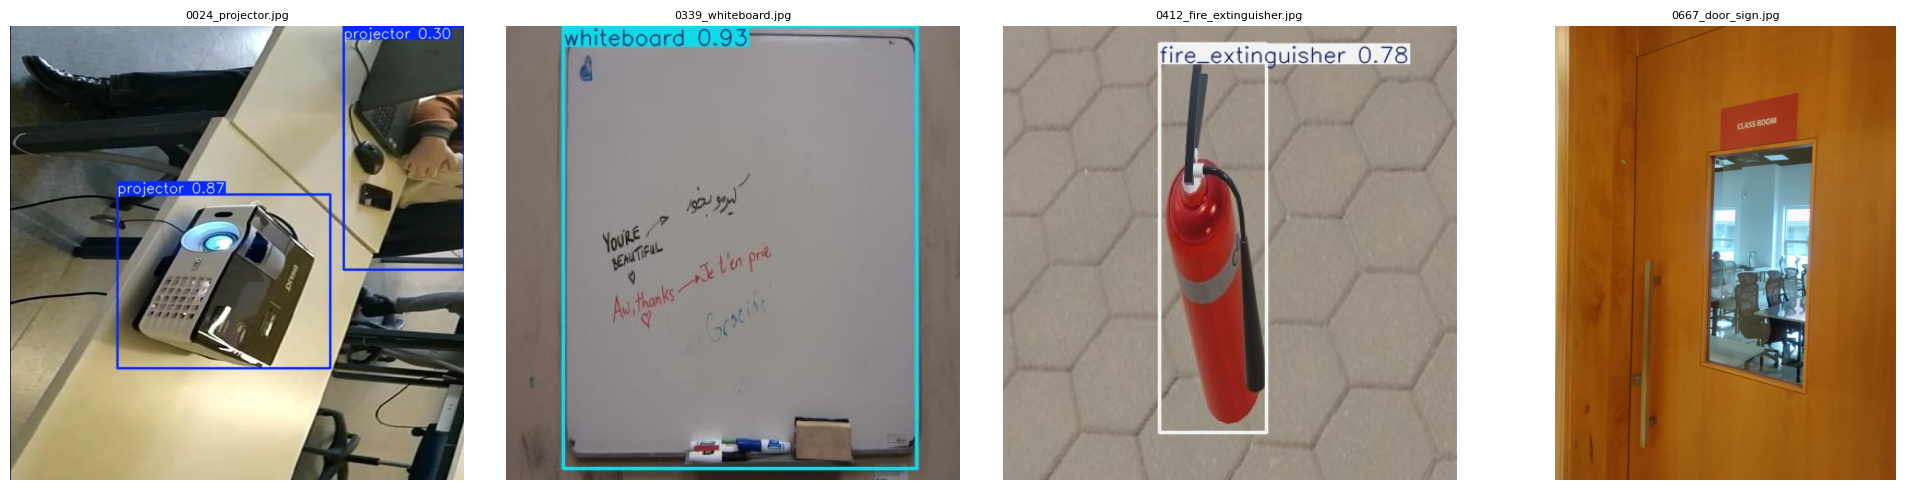

In [10]:
# Display annotated sanity-inference images inline
from PIL import Image

sanity_dir = run_dir / 'sanity'
saved_imgs = sorted(sanity_dir.glob('*.jpg'))

fig, axes = plt.subplots(1, len(saved_imgs), figsize=(5 * len(saved_imgs), 5))
if len(saved_imgs) == 1:
    axes = [axes]
for ax, img_path in zip(axes, saved_imgs):
    ax.imshow(Image.open(img_path))
    ax.set_title(img_path.name, fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

### Expected training indicators
- `val/box_loss` decreases smoothly and plateaus
- `mAP@0.5` > 0.80 on val for all 4 classes within ~60–80 epochs
- No runaway gap between train and val loss

Proceed to **notebook 05** for full evaluation.